---
Phase 1-6: 非監督式學習 (Unsupervised Learning)
---

監督 vs 非監督：
  監督式：有標籤 (y)，學習 X → y 的映射
  非監督式：沒有標籤，學習資料本身的結構

本檔涵蓋：
  Part A: K-Means 聚類（NumPy + sklearn）
  Part B: PCA 主成分分析（NumPy + sklearn）
  Part C: PCA 用於高維資料視覺化

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# Part A: K-Means 聚類
# ============================================================================

/home/acer/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Part A: K-Means 聚類

K-Means 的演算法：
  1. 隨機選 K 個點作為初始「中心」
  2. 把每個資料點分配到最近的中心 → 形成 K 個群
  3. 重新計算每個群的中心（平均值）
  4. 重複 2-3，直到中心不再改變

就像：把一群人分成 K 組，讓每組內的人盡量靠近。

資料: 240 個樣本, 沒有標籤
  收斂於第 2 次迭代
手刻 K-Means 找到的中心:
[[ 3.03 -0.99]
 [ 0.1   3.05]
 [-3.1  -3.  ]]
真實中心: [[-3, -3], [0, 3], [3, -1]]


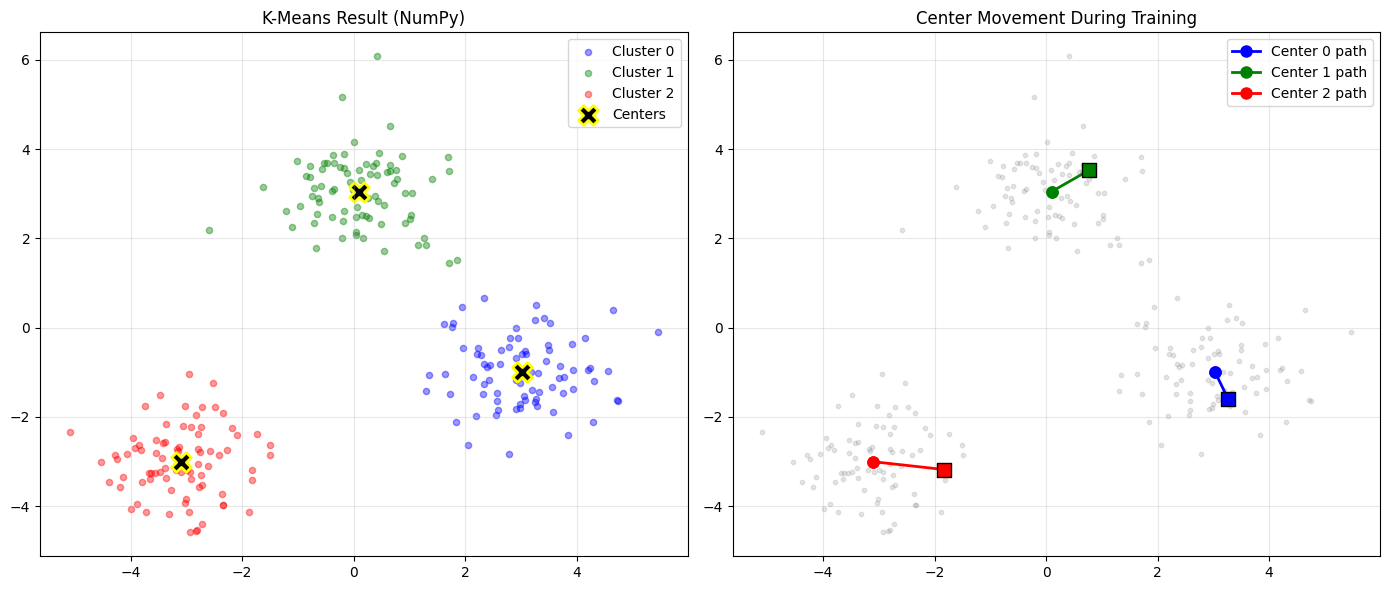

→ 圖表儲存至 plots/06_kmeans.png

--- Scikit-learn K-Means ---


sklearn 中心:
[[ 0.1   3.05]
 [-3.1  -3.  ]
 [ 3.03 -0.99]]
Inertia (越小越好): 292.35

--- Elbow Method：選擇最佳 K ---
  K=1: Inertia=3316.88
  K=2: Inertia=1286.76
  K=3: Inertia=292.35
  K=4: Inertia=254.77
  K=5: Inertia=222.36
  K=6: Inertia=191.81
  K=7: Inertia=167.73
  K=8: Inertia=147.44
  K=9: Inertia=124.47


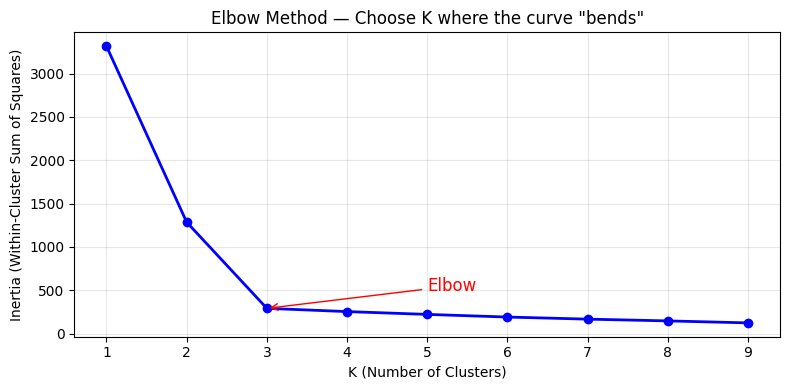

→ 圖表儲存至 plots/06_elbow.png


In [2]:
print("=" * 60)
print("Part A: K-Means 聚類")
print("=" * 60)

print("""
K-Means 的演算法：
  1. 隨機選 K 個點作為初始「中心」
  2. 把每個資料點分配到最近的中心 → 形成 K 個群
  3. 重新計算每個群的中心（平均值）
  4. 重複 2-3，直到中心不再改變

就像：把一群人分成 K 組，讓每組內的人盡量靠近。
""")

# --- 生成資料 ---
np.random.seed(42)
centers_true = [[-3, -3], [0, 3], [3, -1]]
X_list = [np.random.randn(80, 2) * 0.8 + c for c in centers_true]
X = np.vstack(X_list)
np.random.shuffle(X)   # 打亂，假裝我們不知道標籤

print(f"資料: {X.shape[0]} 個樣本, 沒有標籤")

# --- NumPy 手刻 K-Means ---
class KMeans_Numpy:
    def __init__(self, k=3, max_iter=100):
        self.k = k
        self.max_iter = max_iter

    def fit(self, X):
        n_samples = X.shape[0]

        # 1. 隨機初始化中心
        idx = np.random.choice(n_samples, self.k, replace=False)
        self.centers = X[idx].copy()

        self.history = [self.centers.copy()]

        for iteration in range(self.max_iter):
            # 2. 分配：每個點到最近的中心
            distances = np.array([
                np.sqrt(np.sum((X - center) ** 2, axis=1))
                for center in self.centers
            ])   # (k, n_samples)
            self.labels = distances.argmin(axis=0)    # (n_samples,)

            # 3. 更新中心
            new_centers = np.array([
                X[self.labels == i].mean(axis=0) if np.sum(self.labels == i) > 0
                else self.centers[i]
                for i in range(self.k)
            ])

            # 收斂檢查
            shift = np.sqrt(np.sum((new_centers - self.centers) ** 2))
            self.centers = new_centers
            self.history.append(self.centers.copy())

            if shift < 1e-6:
                print(f"  收斂於第 {iteration + 1} 次迭代")
                break

        return self

    def predict(self, X):
        distances = np.array([
            np.sqrt(np.sum((X - center) ** 2, axis=1))
            for center in self.centers
        ])
        return distances.argmin(axis=0)

    def inertia(self, X):
        """計算 Within-Cluster Sum of Squares"""
        labels = self.predict(X)
        total = 0
        for i in range(self.k):
            cluster_points = X[labels == i]
            total += np.sum((cluster_points - self.centers[i]) ** 2)
        return total


np.random.seed(42)
km = KMeans_Numpy(k=3)
km.fit(X)
print(f"手刻 K-Means 找到的中心:\n{km.centers.round(2)}")
print(f"真實中心: {centers_true}")

# 畫聚類結果 + 中心移動過程
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左：最終結果
colors = ['blue', 'green', 'red']
for i in range(3):
    mask = km.labels == i
    axes[0].scatter(X[mask, 0], X[mask, 1], c=colors[i], alpha=0.4, s=20, label=f'Cluster {i}')
axes[0].scatter(km.centers[:, 0], km.centers[:, 1], c='black', marker='X', s=200,
                edgecolors='yellow', linewidths=2, label='Centers')
axes[0].set_title('K-Means Result (NumPy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右：中心移動軌跡
axes[1].scatter(X[:, 0], X[:, 1], c='gray', alpha=0.2, s=10)
for i in range(3):
    trajectory = np.array([h[i] for h in km.history])
    axes[1].plot(trajectory[:, 0], trajectory[:, 1], 'o-', color=colors[i],
                 markersize=8, linewidth=2, label=f'Center {i} path')
    axes[1].scatter(trajectory[0, 0], trajectory[0, 1], marker='s', s=100,
                    c=colors[i], edgecolors='black', zorder=5)
axes[1].set_title('Center Movement During Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase-1-ml-basics/plots/06_kmeans.png', dpi=100)
plt.show()
print("→ 圖表儲存至 plots/06_kmeans.png")

# --- Scikit-learn 版 ---
print("\n--- Scikit-learn K-Means ---")
from sklearn.cluster import KMeans

km_sk = KMeans(n_clusters=3, random_state=42, n_init=10)
km_sk.fit(X)
print(f"sklearn 中心:\n{km_sk.cluster_centers_.round(2)}")
print(f"Inertia (越小越好): {km_sk.inertia_:.2f}")

# --- Elbow Method：怎麼選 K ---
print("\n--- Elbow Method：選擇最佳 K ---")
inertias = []
K_range = range(1, 10)
for k in K_range:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_k.fit(X)
    inertias.append(km_k.inertia_)
    print(f"  K={k}: Inertia={km_k.inertia_:.2f}")

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2)
plt.xlabel('K (Number of Clusters)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method — Choose K where the curve "bends"')
plt.annotate('Elbow', xy=(3, inertias[2]), xytext=(5, inertias[2] + 200),
             arrowprops=dict(arrowstyle='->', color='red'), fontsize=12, color='red')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase-1-ml-basics/plots/06_elbow.png', dpi=100)
plt.show()
print("→ 圖表儲存至 plots/06_elbow.png")

## Part B: PCA 主成分分析


Part B: PCA — 降維

PCA 做什麼？
  把高維資料投影到低維，盡量保留最多資訊。
  找到資料「變異最大」的方向。

演算法：
  1. 資料中心化（減平均值）
  2. 計算共變異數矩陣
  3. 找共變異數矩陣的特徵向量（就是 Phase 0 學的！）
  4. 選前 K 個特徵向量作為投影方向

原始維度: 4D → 降至 2D
各主成分解釋變異比:
  PC1: 0.9246 (92.5%) ██████████████████████████████████████████████
  PC2: 0.0531 (5.3%) ██
  PC3: 0.0171 (1.7%) 
  PC4: 0.0052 (0.5%) 
  前 2 個合計: 97.8%

--- Scikit-learn PCA ---
sklearn 解釋變異比: [0.9246 0.0531]
結果和手刻版相似: True


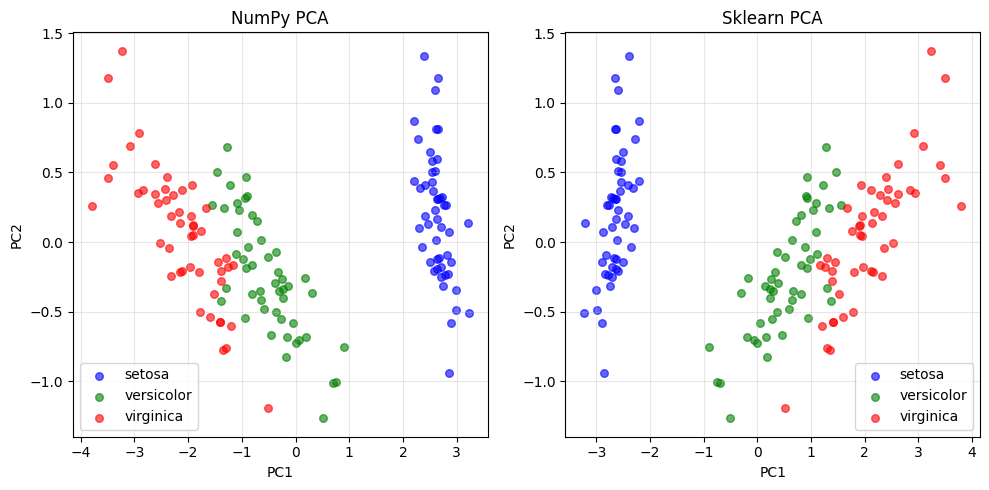

→ 圖表儲存至 plots/06_pca.png


In [3]:
print("\n" + "=" * 60)
print("Part B: PCA — 降維")
print("=" * 60)

print("""
PCA 做什麼？
  把高維資料投影到低維，盡量保留最多資訊。
  找到資料「變異最大」的方向。

演算法：
  1. 資料中心化（減平均值）
  2. 計算共變異數矩陣
  3. 找共變異數矩陣的特徵向量（就是 Phase 0 學的！）
  4. 選前 K 個特徵向量作為投影方向
""")

# --- NumPy 手刻 PCA ---
class PCA_Numpy:
    def __init__(self, n_components=2):
        self.n_components = n_components

    def fit(self, X):
        # 1. 中心化
        self.mean = X.mean(axis=0)
        X_centered = X - self.mean

        # 2. 共變異數矩陣
        cov_matrix = (X_centered.T @ X_centered) / (len(X) - 1)

        # 3. 特徵值分解
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # 排序（從大到小）
        idx = eigenvalues.argsort()[::-1]
        self.eigenvalues = eigenvalues[idx]
        self.components = eigenvectors[:, idx]    # 每一行是一個主成分

        # 解釋變異比
        self.explained_variance_ratio = self.eigenvalues / self.eigenvalues.sum()

        return self

    def transform(self, X):
        X_centered = X - self.mean
        return X_centered @ self.components[:, :self.n_components]

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


# 用 Iris 4D 資料降到 2D
from sklearn.datasets import load_iris
iris = load_iris()

pca_np = PCA_Numpy(n_components=2)
X_2d = pca_np.fit_transform(iris.data)

print(f"原始維度: {iris.data.shape[1]}D → 降至 2D")
print(f"各主成分解釋變異比:")
for i, ratio in enumerate(pca_np.explained_variance_ratio):
    bar = '█' * int(ratio * 50)
    print(f"  PC{i+1}: {ratio:.4f} ({ratio:.1%}) {bar}")
print(f"  前 2 個合計: {pca_np.explained_variance_ratio[:2].sum():.1%}")

# --- Scikit-learn PCA ---
print("\n--- Scikit-learn PCA ---")
from sklearn.decomposition import PCA

pca_sk = PCA(n_components=2)
X_2d_sk = pca_sk.fit_transform(iris.data)

print(f"sklearn 解釋變異比: {pca_sk.explained_variance_ratio_.round(4)}")
print(f"結果和手刻版相似: {np.allclose(np.abs(X_2d), np.abs(X_2d_sk), atol=0.01)}")
# 注意：特徵向量的正負方向可能不同，但投影結果等價

# 視覺化
plt.figure(figsize=(10, 5))

for i, (data, title) in enumerate([(X_2d, "NumPy PCA"), (X_2d_sk, "Sklearn PCA")]):
    plt.subplot(1, 2, i + 1)
    for c, name, color in zip([0, 1, 2], iris.target_names, ['blue', 'green', 'red']):
        mask = iris.target == c
        plt.scatter(data[mask, 0], data[mask, 1], c=color, alpha=0.6, s=30, label=name)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phase-1-ml-basics/plots/06_pca.png', dpi=100)
plt.show()
print("→ 圖表儲存至 plots/06_pca.png")

## Part C: PCA 用於高維資料（MNIST 手寫數字）


Part C: PCA 視覺化高維資料 (MNIST)
MNIST-small: 1797 張圖, 每張 64 維 (8x8 像素)
降至 2D 後的解釋變異比: 28.5%


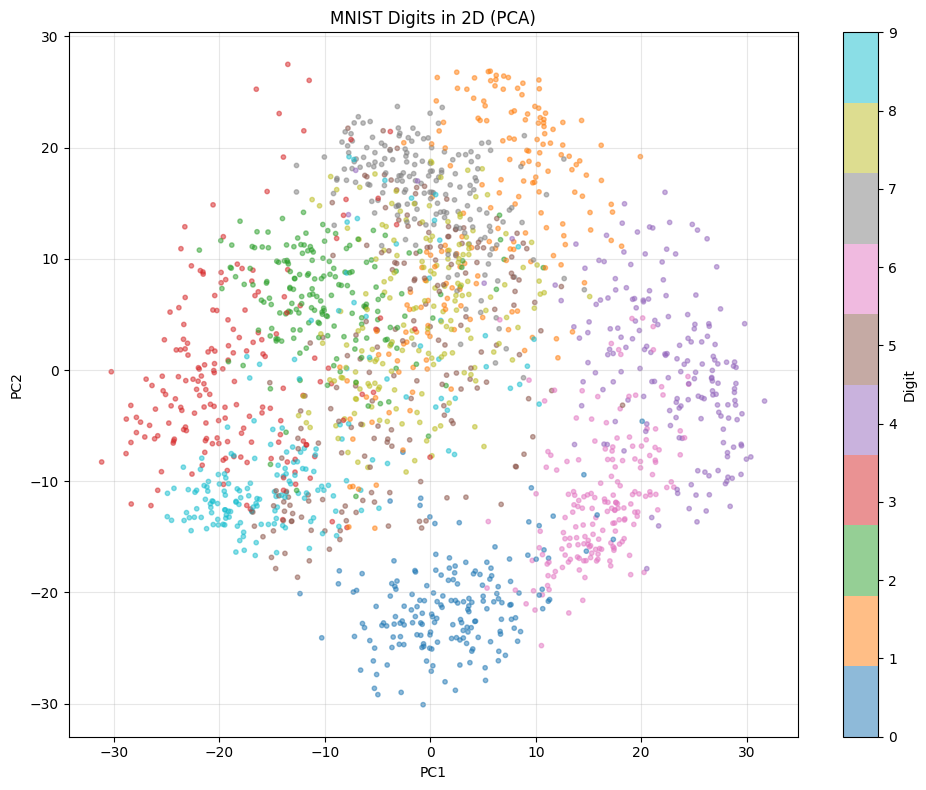

→ 圖表儲存至 plots/06_pca_mnist.png
  觀察：同一個數字的點大致聚在一起，PCA 發現了結構！


In [4]:
print("\n" + "=" * 60)
print("Part C: PCA 視覺化高維資料 (MNIST)")
print("=" * 60)

from sklearn.datasets import load_digits

digits = load_digits()
print(f"MNIST-small: {digits.data.shape[0]} 張圖, 每張 {digits.data.shape[1]} 維 (8x8 像素)")

# 784 維 → 2 維
pca_digits = PCA(n_components=2)
X_digits_2d = pca_digits.fit_transform(digits.data)

print(f"降至 2D 後的解釋變異比: {pca_digits.explained_variance_ratio_.sum():.1%}")

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_digits_2d[:, 0], X_digits_2d[:, 1],
                       c=digits.target, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Digit')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('MNIST Digits in 2D (PCA)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phase-1-ml-basics/plots/06_pca_mnist.png', dpi=100)
plt.show()
print("→ 圖表儲存至 plots/06_pca_mnist.png")
print("  觀察：同一個數字的點大致聚在一起，PCA 發現了結構！")

## 小結

In [5]:
print("\n" + "=" * 60)
print("小結")
print("=" * 60)
print("""
非監督式學習教會你的核心概念：

  概念                 對應到深度學習
  ──────────────────────────────────────────────
  K-Means 聚類        →  向量量化 (VQ-VAE)、Tokenizer 建詞表
  PCA 降維            →  理解 Embedding 的概念
  保留最大變異方向     →  Autoencoder 的壓縮思想
  高維視覺化          →  t-SNE/UMAP 觀察 Embedding 空間

sklearn 速查：
  # K-Means
  from sklearn.cluster import KMeans
  km = KMeans(n_clusters=3)
  km.fit(X)
  km.labels_            # 聚類標籤
  km.cluster_centers_   # 中心
  km.inertia_          # WCSS

  # PCA
  from sklearn.decomposition import PCA
  pca = PCA(n_components=2)
  X_2d = pca.fit_transform(X)
  pca.explained_variance_ratio_

下一步：07_model_evaluation.py — 怎麼正確評估模型
""")


小結

非監督式學習教會你的核心概念：

  概念                 對應到深度學習
  ──────────────────────────────────────────────
  K-Means 聚類        →  向量量化 (VQ-VAE)、Tokenizer 建詞表
  PCA 降維            →  理解 Embedding 的概念
  保留最大變異方向     →  Autoencoder 的壓縮思想
  高維視覺化          →  t-SNE/UMAP 觀察 Embedding 空間

sklearn 速查：
  # K-Means
  from sklearn.cluster import KMeans
  km = KMeans(n_clusters=3)
  km.fit(X)
  km.labels_            # 聚類標籤
  km.cluster_centers_   # 中心
  km.inertia_          # WCSS

  # PCA
  from sklearn.decomposition import PCA
  pca = PCA(n_components=2)
  X_2d = pca.fit_transform(X)
  pca.explained_variance_ratio_

下一步：07_model_evaluation.py — 怎麼正確評估模型

